In [2]:
import numpy as np
import os
from PIL import Image

In [50]:
base_pth = "examples/gw_grip_home/data_dir/episodes/gpt4o_HOR3_cond-True_views_full_inst/episode_0008/STEP_0.json"

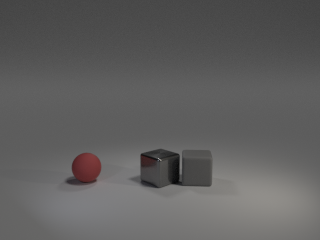

In [3]:
STEP = 1

npz = np.load('examples/prb/data_dir/episodes/gpt41_HOR3_cond-True__(3,5)/episode_0000/renders/STEP_0.npz')
Image.fromarray(npz['frontview'])

In [15]:
system = "You will be asked questions about the state of blocks in a given image.\nA block can be a cube, cylinder, or sphere.\nA block is considered on the table if it is not on top of any other block.\nThe top of a block is considered clear if no other block is on top of it.\nBlocks come in one of two materials, rubber and metal. Rubber blocks have a matte finish while metal objects are glossy and reflective."

In [8]:
from semantic_state_estimator.semantic_state_estimator import *
from semantic_state_estimator.constants import GPT_41_LATEST

/home/guy.azran/miniforge3/envs/s3e/lib/python3.10/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [4]:
npz = np.load('examples/prb/data_dir/episodes/gpt41_HOR3_cond-True__(3,5)/episode_0000/renders/STEP_0.npz')
imgs = [Image.fromarray(npz[k]) for k in npz.keys()]

In [16]:
se = SemanticStateEstimator('examples/prb/data_dir/episodes/gpt41_HOR3_cond-True__(3,5)/episode_0000/domain.pddl',
                            'examples/prb/data_dir/episodes/gpt41_HOR3_cond-True__(3,5)/episode_0000/problem.pddl',
                            GPT_41_LATEST,
                            GPT_41_LATEST,
                            additional_instructions=system)
print(se.vqa_model.system_prompt)

predicate queries loaded from cache
A curious human is asking an artificial intelligence assistant yes or no questions. The assistant answers with one of two responses: YES or NO. The assistant's response should not include any additional text.
Additional Instructions and clarifications:
You will be asked questions about the state of blocks in a given image.
A block can be a cube, cylinder, or sphere.
A block is considered on the table if it is not on top of any other block.
The top of a block is considered clear if no other block is on top of it.
Blocks come in one of two materials, rubber and metal. Rubber blocks have a matte finish while metal objects are glossy and reflective.


In [17]:
state = se.estimate_state(imgs)
state

  0%|          | 0/12 [00:00<?, ?it/s]

{'is_directly_on_table(large_grey_metal_cube)': 0.9999832985848847,
 'is_directly_on_table(large_grey_rubber_cube)': 0.9999999992417439,
 'is_directly_on_table(large_red_rubber_sphere)': 0.999999974890009,
 'is_clear_on_top(large_grey_metal_cube)': 0.9999999956365377,
 'is_clear_on_top(large_grey_rubber_cube)': 0.999999999683912,
 'is_clear_on_top(large_red_rubber_sphere)': 0.999999999994891,
 'shape_on_top_of_block(large_grey_metal_cube,large_grey_metal_cube)': 2.88235079342213e-13,
 'shape_on_top_of_block(large_grey_metal_cube,large_grey_rubber_cube)': 3.939706424134803e-13,
 'shape_on_top_of_block(large_grey_rubber_cube,large_grey_metal_cube)': 0.0,
 'shape_on_top_of_block(large_grey_rubber_cube,large_grey_rubber_cube)': 3.266131342784388e-13,
 'shape_on_top_of_block(large_red_rubber_sphere,large_grey_metal_cube)': 0.0,
 'shape_on_top_of_block(large_red_rubber_sphere,large_grey_rubber_cube)': 0.0}

In [4]:
se = SemanticStateEstimator('examples/gw_grip/domain.pddl', 'examples/gw_grip/problem.pddl', GPT_41_LATEST, GPT_41_LATEST, additional_instructions="The user will show you images of a simulated robot and ask questions about the state of the environment.\nThere are three tables: a brown wood table, a black table, and a white table.\nThe robot has a black two finger gripper at its end effector with which it can grasp objects. Objects are considered gripped if they are in between the gripper fingers. If no object is in between the two gripper fingers, the robot gripper is considered to be empty.\nThe milk carton is a clean white rectangular box with a triangular top.\nWhen the robot is holding the milk carton it looks like there is a white rectangular object being pinched by the robot's gripper.\nThe loaf of bread looks like a small brown box.\nWhen the robot is gripping the loaf of bread it looks like there is a small brown object inside the robot gripper.\nThe red can of soda is a small red cylinder with some white labeling on it.\nThe red box of cereal is a tall box with an illustration on its wide sides.")
print(se.vqa_model.system_prompt)

predicate queries loaded from cache
A curious human is asking an artificial intelligence assistant yes or no questions. The assistant answers with one of two responses: YES or NO. The assistant's response should not include any additional text.
Additional Instructions and clarifications:
The user will show you images of a simulated robot and ask questions about the state of the environment.
There are three tables: a brown wood table, a black table, and a white table.
The robot has a black two finger gripper at its end effector with which it can grasp objects. Objects are considered gripped if they are in between the gripper fingers. If no object is in between the two gripper fingers, the robot gripper is considered to be empty.
The milk carton is a clean white rectangular box with a triangular top.
When the robot is holding the milk carton it looks like there is a white rectangular object being pinched by the robot's gripper.
The loaf of bread looks like a small brown box.
When the rob

In [5]:
state = se.estimate_state(imgs)
state

  0%|          | 0/25 [00:00<?, ?it/s]

{'on-table(milk-carton,wood-table)': 0.9999999999622486,
 'on-table(milk-carton,black-table)': 2.0007480103597372e-12,
 'on-table(milk-carton,white-table)': 5.38494021772185e-13,
 'on-table(lemon,wood-table)': 0.0,
 'on-table(lemon,black-table)': 0.0,
 'on-table(lemon,white-table)': 0.9999999999898395,
 'on-table(green-bottle,wood-table)': 0.0,
 'on-table(green-bottle,black-table)': 0.047425883194038745,
 'on-table(green-bottle,white-table)': 0.0,
 'on-table(loaf-of-bread,wood-table)': 0.9999999999852163,
 'on-table(loaf-of-bread,black-table)': 7.835041784813037e-13,
 'on-table(loaf-of-bread,white-table)': 1.3046515881978704e-11,
 'on-table(red-box-of-cereal,wood-table)': 6.495477781904047e-13,
 'on-table(red-box-of-cereal,black-table)': 0.0,
 'on-table(red-box-of-cereal,white-table)': 0.9999999999771028,
 'on-table(red-can-of-soda,wood-table)': 3.978962535805575e-12,
 'on-table(red-can-of-soda,black-table)': 0.0,
 'on-table(red-can-of-soda,white-table)': 0.0,
 'robot-gripper-empty()':